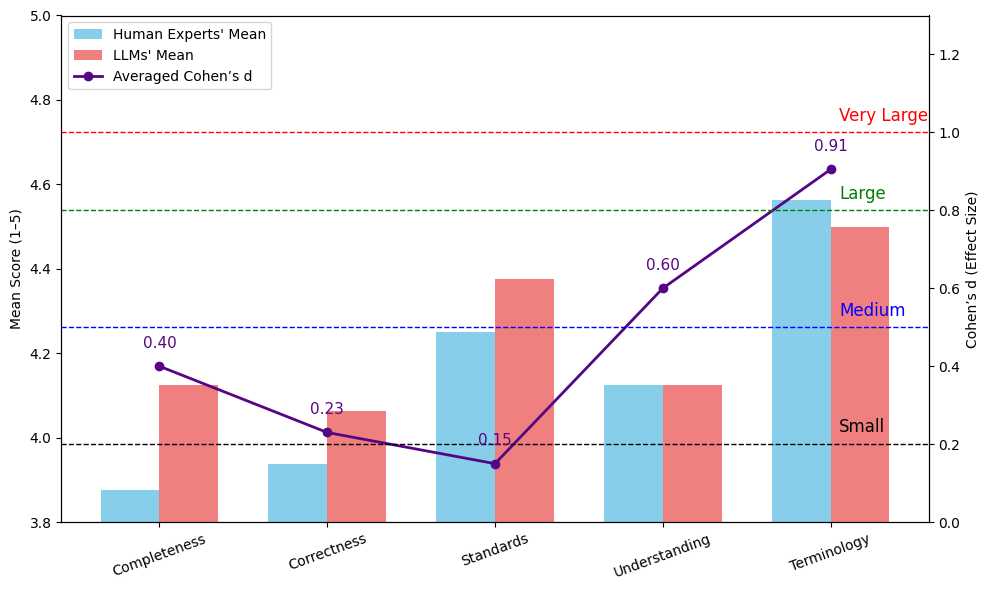

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ----- Data -----
criteria = ["Completeness", "Correctness", "Standards", "Understanding", "Terminology"]
llm_means = [4.125, 4.062, 4.375, 4.125, 4.50]
human_means = [3.875, 3.938, 4.250, 4.125, 4.562]

# Original LLM and Human Cohen's d
llm_d = [0.30, 0.18, 0.30, 0.86, np.inf]
human_d = [0.50, 0.28, 0.00, 0.34, 0.61]

# Cap infinite values for plotting
llm_d_display = [min(d, 1.2) for d in llm_d]

# Calculate approximate overall Cohen's d per criterion
overall_d = [(l + h)/2 for l, h in zip(llm_d_display, human_d)]

x = np.arange(len(criteria))
width = 0.35

# ----- Figure setup -----
fig, ax1 = plt.subplots(figsize=(10,6))

# Bar chart for mean scores
bars1 = ax1.bar(x - width/2, human_means, width, label="Human Experts' Mean", color='skyblue')
bars2 = ax1.bar(x + width/2, llm_means, width, label="LLMs' Mean", color='lightcoral')

ax1.set_ylabel("Mean Score (1–5)")
ax1.set_ylim(3.8, 5)
ax1.set_xticks(x)
ax1.set_xticklabels(criteria, rotation=20)
# ax1.set_title("Human–LLM Alignment")

# ----- Second y-axis for overall Cohen's d -----
ax2 = ax1.twinx()
ax2.plot(x, overall_d, color='#540684', marker='o', linewidth=2, label="Averaged Cohen’s d")
ax2.set_ylabel("Cohen’s d (Effect Size)")
ax2.set_ylim(-0.0, 1.3)

# Threshold lines for interpretation
for level, color, label in [(0.2, 'black', 'Small'), (0.5, 'blue', 'Medium'), (0.8, 'green', 'Large'), (1.0, 'red', 'Very Large')]:
    ax2.axhline(level, color=color, linestyle='--', linewidth=1)
    ax2.text(len(criteria)-0.95, level+0.03, label, color=color, fontsize=12)

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# Annotate overall Cohen’s d values
for i, d in enumerate(overall_d):
    ax2.text(x[i], d + 0.04 if d >= 0 else d - 0.08, f"{d:.2f}", ha='center', va='bottom' if d >= 0 else 'top', fontsize=11, color='#540684')

plt.tight_layout()
plt.show()
